#                                    1. Logistic Regression :)

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [4]:
cd C:\Users\saite\Desktop\MODELS_SCRATCH

C:\Users\saite\Desktop\MODELS_SCRATCH


In [5]:
data = pd.read_csv('Breast_cancer_data.csv')

In [6]:
data.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [7]:

X=data.drop('diagnosis',axis=1)
y=data['diagnosis']

In [8]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2, random_state= 42, shuffle=True)


In [10]:
def sigmoid(x):
    return (1/(1+np.exp(-x)))
    

In [11]:
def grad_desc(x, y, theta, alpha, num_iters):
    loss =[]
    m=len(X)

    for i in range(0, num_iters):
        z = np.dot(x,theta)
        h = sigmoid(z)
        theta -= (alpha/m)*(np.dot(np.transpose(x),(h-y)))
        loss.append((-1/m)*(np.dot(np.transpose(y),np.log(h))+np.dot((1-np.transpose(y)),(np.log(1-h)))))
    return loss,theta

In [12]:
loss, theta = grad_desc(X_train, y_train,np.random.rand(X.shape[1]), 0.09, 2000)
print(f"The cost after training loss:",np.squeeze(loss))
print(f"The resulting vector of weights is :",theta)


The cost after training loss: [0.75989646 0.74728859 0.73506904 ... 0.28592829 0.2858985  0.28586873]
The resulting vector of weights is : [-2.68778654 -0.30626911 -2.78924694  1.76747866 -1.14383622]


In [13]:
def predict( X):        
    z = np.dot(X, theta)
    return [1 if i > 0.5 else 0 for i in sigmoid(z)]

In [14]:
y_pred = predict(X_test)


In [15]:

print(classification_report(y_test, y_pred))
print('-'*55)
print('Confusion Matrix\n')
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75        43
           1       0.81      1.00      0.89        71

    accuracy                           0.85       114
   macro avg       0.90      0.80      0.82       114
weighted avg       0.88      0.85      0.84       114

-------------------------------------------------------
Confusion Matrix

[[26 17]
 [ 0 71]]


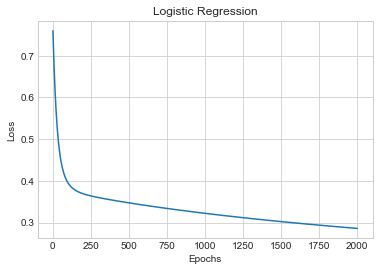

In [16]:
plt.style.use('seaborn-whitegrid')
plt.plot(loss)
plt.title('Logistic Regression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()